# HDI Project – E2E

This notebook contains a comprehensive HDI modeling workflow in Python, including data preprocessing, feature engineering, and predictive modeling, with a focus on generating insights relevant to development outcomes.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import re

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

## 2. Load & Merge Data

In [2]:
df_wdi = pd.read_csv('wdi_selected_indicators.csv')
df_hdi = pd.read_excel('hdi_undp.xlsx')  

# --- Clean WDI Data ---

# Strip column names
df_wdi.columns = df_wdi.columns.str.strip()

# Fix year columns like '2014 [YR2014]'
df_wdi.columns = [col.split()[0] if '[YR' in col else col for col in df_wdi.columns]

# Melt years into rows
df_long = df_wdi.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    var_name='Year',
    value_name='Value'
)

# Convert values to numeric
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Remove duplicates by averaging
df_long = df_long.groupby(
    ['Country Name', 'Country Code', 'Year', 'Series Name'],
    as_index=False
)['Value'].mean()

# Pivot to wide format
df_wdi_clean = df_long.pivot(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='Value'
).reset_index()
df_wdi_clean.columns.name = None

# Convert Year to int
df_wdi_clean['Year'] = df_wdi_clean['Year'].astype(int)

# Standardize column names
def standardize(col):
    col = col.strip().lower()
    col = re.sub(r'\(.*?\)', '', col)   # remove brackets
    col = re.sub(r'[^a-z0-9]+', '_', col)
    return col.strip('_')

df_wdi_clean.columns = [standardize(c) for c in df_wdi_clean.columns]

# Rename key indicators
rename_dict = {
    'individuals_using_the_internet': 'internet_users_pct',
    'inflation_consumer_prices': 'inflation_pct',
    'gdp_per_capita_ppp': 'gdp_per_capita_ppp',
    'gdp_per_capita_growth': 'gdp_per_capita_growth_pct',
    'gdp_growth': 'gdp_growth_pct',
    'military_expenditure': 'military_exp_pct_gdp',
    'mobile_cellular_subscriptions': 'mobile_subscriptions_per_100',
    'under_five_deaths': 'under5_deaths',
    'infant_deaths': 'infant_deaths',
    'health_expenditure': 'health_exp_pct_gdp',
    'access_to_clean_fuels_and_technologies_for_cooking': 'clean_fuel_access_pct',
    'age_dependency_ratio_young': 'young_dependency_ratio',
    'birth_rate_crude': 'birth_rate_per_1000',
    'employment_in_agriculture': 'employment_agri_pct',
    'employment_in_agriculture_female': 'female_employment_agri_pct',
    'school_enrollment_primary': 'primary_enrollment_pct',
    'sex_ratio_at_birth': 'sex_ratio_birth',
    'statistical_performance_indicators_spi_pillar_5_data_infrastructure_score': 'spi_data_infrastructure_score'
}
df_wdi_clean = df_wdi_clean.rename(columns=rename_dict)

# --- Clean HDI Data ---
df_hdi = df_hdi[['countryIsoCode', 'country', 'indicatorCode', 'year', 'value']]
df_hdi = df_hdi.rename(columns={
    'countryIsoCode': 'country_code',
    'country': 'country_name',
    'value': 'hdi'
})
df_hdi = df_hdi.drop(columns=['indicatorCode'])

# Keep only necessary columns from WDI (drop country_name from WDI)
df_wdi_merge = df_wdi_clean.drop(columns=['country_name'])

# Merge with HDI, which has the country_name you want
df = df_wdi_merge.merge(
    df_hdi[['country_code', 'year', 'hdi', 'country_name']],
    on=['country_code', 'year'],
    how='inner'
)

# Remove duplicates and rows with missing HDI
df = df.drop_duplicates()
df = df.dropna(subset=['hdi'])

df.shape

(2114, 31)

In [3]:
df.head(2)

,country_code,year,clean_fuel_access_pct,access_to_electricity,young_dependency_ratio,current_health_expenditure,death_rate_crude,employers_female,employers_total,gdp_growth_pct,...,population_growth,primary_enrollment_pct,sex_ratio_birth,statistical_performance_indicators_pillar_5_data_infrastructure_score,time_required_to_obtain_an_operating_license,time_spent_dealing_with_the_requirements_of_government_regulations,trade,urban_population,hdi,country_name
0,AFG,2014,25.8,89.5,91.719424,9.528878,7.511,0.413928,1.295215,2.724543,...,3.632519,109.829453,1.056,NaN,13.717754,9.797834,NaN,24.191017,0.497,Afghanistan
1,AFG,2015,27.5,71.5,90.026791,10.105348,7.528,0.526911,1.494608,1.451315,...,3.119959,106.773552,1.056,NaN,NaN,NaN,NaN,24.464912,0.496,Afghanistan


## 3. Summary Stats BEFORE Processing

In [4]:
def summary_table(data):
    return pd.DataFrame({
        'mean': data.mean(),
        'median': data.median(),
        'std_dev': data.std(),
        'skewness': data.skew(),
        'min': data.min(),
        'max': data.max(),
        'missing_pct': data.isnull().mean()*100
    })

num_cols = df.select_dtypes(include='number').columns
summary_before = summary_table(df[num_cols])
summary_before.head()

,mean,median,std_dev,skewness,min,max,missing_pct
year,2018.912961,2019.000000,3.030683,-0.110865,2014.000000,2023.000000,0.000000
clean_fuel_access_pct,68.295288,89.700000,37.418775,-0.738787,0.000000,100.000000,3.122044
access_to_electricity,84.710643,99.800000,25.457906,-1.609466,4.200000,100.000000,0.000000
young_dependency_ratio,45.233921,39.598194,21.876050,0.661815,15.518704,102.245229,0.000000
current_health_expenditure,6.694490,6.246778,3.059337,1.347998,1.326516,27.089685,0.993377


## 4. Initial Missing Value Handling (>25%)

In [5]:
# Calculate missing percentage per column
missing_pct = df.isnull().mean() * 100

# Drop columns with >50% missing
cols_to_drop = missing_pct[missing_pct > 50].index
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns (>50% missing):")
for col in cols_to_drop:
    print(f"- {col}")

print("\nRemaining missing values (per column):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dropped 2 columns (>50% missing):
- time_required_to_obtain_an_operating_license
- time_spent_dealing_with_the_requirements_of_government_regulations

Remaining missing values (per column):
clean_fuel_access_pct                                                     66
current_health_expenditure                                                21
employers_female                                                         161
employers_total                                                          161
gdp_growth_pct                                                            39
gdp_per_capita_growth_pct                                                 39
gni_per_capita_growth                                                    445
gni_per_capita_ppp                                                        77
internet_users_pct                                                       108
inflation_pct                                                            155
military_exp_pct_gdp                    

## 5. Imputation (KNN)

In [6]:
from sklearn.impute import KNNImputer

num_cols = df.select_dtypes(include=['number']).columns

imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

# Verify no missing values
print("\nMissing values after KNN imputation:")
print(df[num_cols].isnull().sum().sum())  # should be 0


Missing values after KNN imputation:
0


## 6. Handle Skewness

In [7]:
df_transformed = df.copy()

num_cols = df_transformed.select_dtypes(include=['number']).columns

# Compute skewness
skewed_cols = df_transformed[num_cols].skew()
skewed_cols = skewed_cols[abs(skewed_cols) > 3].index

# Keep only existing columns
skewed_cols = [col for col in skewed_cols if col in df_transformed.columns]

print("Highly skewed variables:", skewed_cols)

# Apply log1p only on strictly positive columns
for col in skewed_cols:
    if (df_transformed[col] > 0).all():
        df_transformed[col] = np.log1p(df_transformed[col])
    else:
        print(f"Skipping {col} due to non-positive values")

Highly skewed variables: ['employers_female', 'inflation_pct', 'military_exp_pct_gdp', 'number_of_infant_deaths', 'number_of_under_five_deaths', 'oil_rents', 'sex_ratio_birth', 'hdi']
Skipping inflation_pct due to non-positive values
Skipping number_of_infant_deaths due to non-positive values
Skipping number_of_under_five_deaths due to non-positive values
Skipping oil_rents due to non-positive values


## 7. Handle Outliers (IQR Capping)

In [8]:
df_outliers = df_transformed.copy()

for col in num_cols:
    Q1 = df_outliers[col].quantile(0.25)
    Q3 = df_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_outliers[col] = np.clip(df_outliers[col], lower, upper)

## 8. Standardization

In [9]:
scaler = StandardScaler()

df_scaled = df_outliers.copy()
df_scaled[num_cols] = scaler.fit_transform(df_outliers[num_cols])

## 9. Summary AFTER Processing

In [10]:
summary_after = summary_table(df_scaled[num_cols])

comparison = summary_before.merge(
    summary_after, left_index=True, right_index=True,
    suffixes=('_before', '_after')
)

comparison.head()

,mean_before,median_before,std_dev_before,skewness_before,min_before,max_before,missing_pct_before,mean_after,median_after,std_dev_after,skewness_after,min_after,max_after,missing_pct_after
year,2018.912961,2019.000000,3.030683,-0.110865,2014.000000,2023.000000,0.000000,3.669807e-14,0.028726,1.000237,-0.110865,-1.621458,1.348873,0.0
clean_fuel_access_pct,68.295288,89.700000,37.418775,-0.738787,0.000000,100.000000,3.122044,6.722259e-18,0.566138,1.000237,-0.752230,-1.847228,0.849270,0.0
access_to_electricity,84.710643,99.800000,25.457906,-1.609466,4.200000,100.000000,0.000000,3.562797e-16,0.629398,1.000237,-1.281097,-2.139191,0.638855,0.0
young_dependency_ratio,45.233921,39.598194,21.876050,0.661815,15.518704,102.245229,0.000000,5.377807e-17,-0.257682,1.000237,0.661815,-1.358666,2.606723,0.0
current_health_expenditure,6.694490,6.246778,3.059337,1.347998,1.326516,27.089685,0.993377,-3.293907e-16,-0.135445,1.000237,0.637689,-1.894853,2.814585,0.0


## 10. Train/Test Split

In [11]:
X = df_scaled.drop(columns=['hdi'])
y = df_scaled['hdi']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

## 11. Linear Regression

In [12]:
# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numeric columns: ['year', 'clean_fuel_access_pct', 'access_to_electricity', 'young_dependency_ratio', 'current_health_expenditure', 'death_rate_crude', 'employers_female', 'employers_total', 'gdp_growth_pct', 'gdp_per_capita_growth_pct', 'gni_per_capita_growth', 'gni_per_capita_ppp', 'internet_users_pct', 'inflation_pct', 'life_expectancy_at_birth_total', 'military_exp_pct_gdp', 'mobile_subscriptions_per_100', 'number_of_infant_deaths', 'number_of_under_five_deaths', 'oil_rents', 'population_growth', 'primary_enrollment_pct', 'sex_ratio_birth', 'statistical_performance_indicators_pillar_5_data_infrastructure_score', 'trade', 'urban_population']
Categorical columns: ['country_code', 'country_name']


In [13]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)

# Ensure validation set has same columns
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Fill any remaining NaNs with 0
X_train_encoded = X_train_encoded.fillna(0)
X_val_encoded = X_val_encoded.fillna(0)

# Fit model
lr = LinearRegression()
lr.fit(X_train_encoded, y_train)

y_pred_val = lr.predict(X_val_encoded)
lr_mse = mean_squared_error(y_val, y_pred_val)

print("Linear Regression MSE:", lr_mse)

Linear Regression MSE: 0.6643584433558547


## 12. Decision Tree

In [15]:
from sklearn.tree import DecisionTreeRegressor

# Use the same one-hot encoded features as LR
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train_encoded, y_train)

y_pred_val_tree = tree.predict(X_val_encoded)
tree_mse = mean_squared_error(y_val, y_pred_val_tree)

print("Decision Tree MSE:", tree_mse)

Decision Tree MSE: 0.6331479753585483


## 13. Feature Importance

In [16]:
# Feature importance
importance = pd.Series(tree.feature_importances_, index=X_train_encoded.columns)
importance = importance.sort_values(ascending=False)

# Top 10 features
print("Top 10 features by importance:")
print(importance.head(10))

Top 10 features by importance:
access_to_electricity             0.420457
year                              0.305551
gni_per_capita_ppp                0.102086
young_dependency_ratio            0.082216
life_expectancy_at_birth_total    0.025018
gdp_growth_pct                    0.014711
mobile_subscriptions_per_100      0.012844
death_rate_crude                  0.012281
gdp_per_capita_growth_pct         0.008646
population_growth                 0.005827
dtype: float64


## 14. Feature Importance Visualization

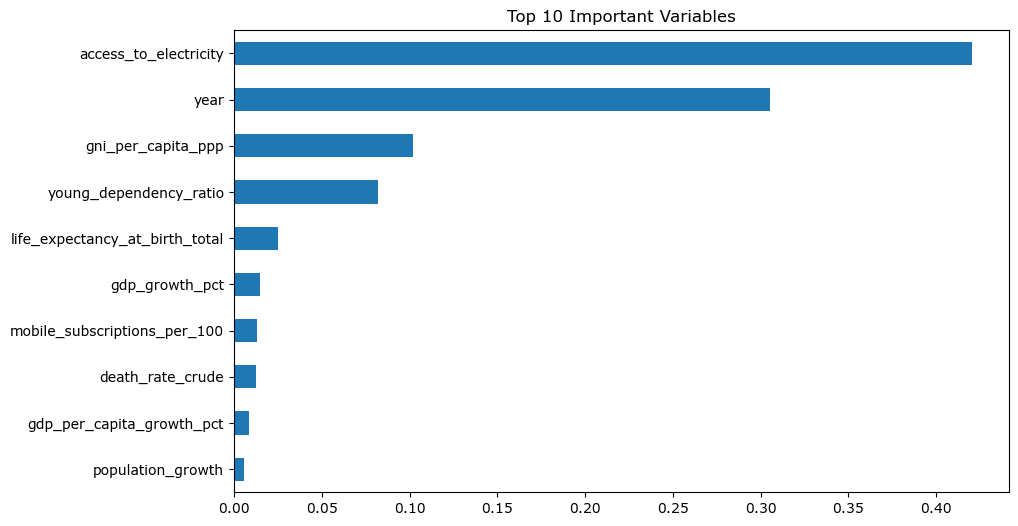

In [17]:
plt.figure(figsize=(10,6))
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Variables")
plt.gca().invert_yaxis()
plt.show()

## 15. Correlation Analysis

In [18]:
# Select only numeric columns
numeric_df = df_scaled.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Correlation with HDI
hdi_corr = corr_matrix['hdi'].sort_values(ascending=False)

print("Top 10 positive correlations with HDI:")
print(hdi_corr.head(10))

print("\nTop 10 negative correlations with HDI:")
print(hdi_corr.tail(10))

Top 10 positive correlations with HDI:
hdi                                                                      1.000000
life_expectancy_at_birth_total                                           0.624883
internet_users_pct                                                       0.618473
clean_fuel_access_pct                                                    0.567323
access_to_electricity                                                    0.566700
gni_per_capita_ppp                                                       0.514915
statistical_performance_indicators_pillar_5_data_infrastructure_score    0.492977
mobile_subscriptions_per_100                                             0.467389
urban_population                                                         0.435961
year                                                                     0.339557
Name: hdi, dtype: float64

Top 10 negative correlations with HDI:
employers_total                0.044161
gni_per_capita_growth          0.03

## 16. Clustering

In [19]:
# -------------------------------
# Cluster Analysis
# -------------------------------
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only (exclude 'hdi')
X_cluster = df_scaled.select_dtypes(include=['number']).drop(columns=['hdi'])

# Initialize KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(X_cluster)

# Optional: view first rows with cluster assignments
if 'country' in df_scaled.columns:
    display(df_scaled[['country', 'cluster']].head())

/private/var/containers/Bundle/Application/B56B215E-1FAB-444D-A05C-9E94DC29BAEF/Carnets-sci.app/Library/lib/python3.13/site-packages/threadpoolctl.py:990: RuntimeWarning: Could not find dl_iterate_phdr in the C standard library.
  warnings.warn(


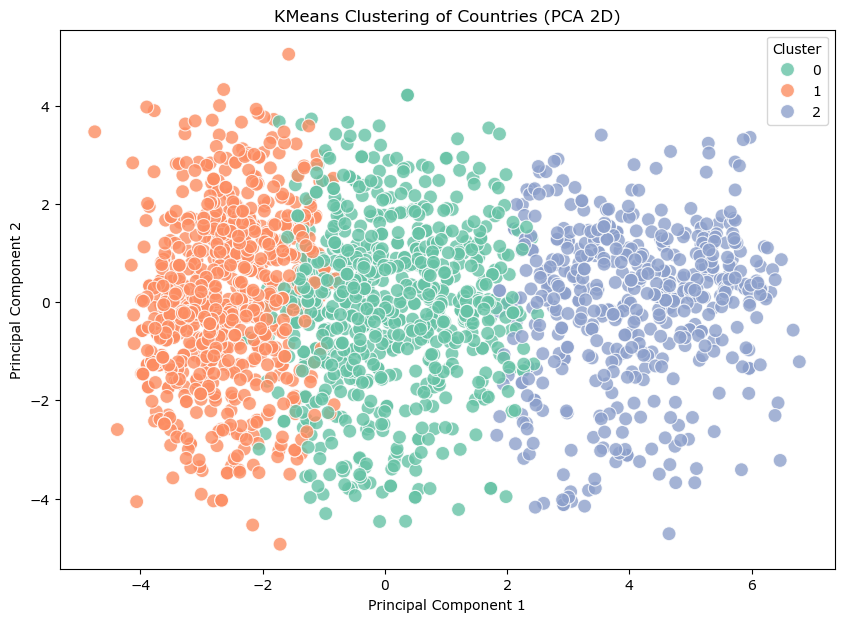

In [20]:
# -------------------------------
# PCA 2D Scatter Plot
# -------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# Create DataFrame for plotting
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['cluster'] = df_scaled['cluster'].values

if 'country' in df_scaled.columns:
    plot_df['country'] = df_scaled['country'].values

plt.figure(figsize=(10,7))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='Set2', s=100, alpha=0.8)

plt.title("KMeans Clustering of Countries (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.show()

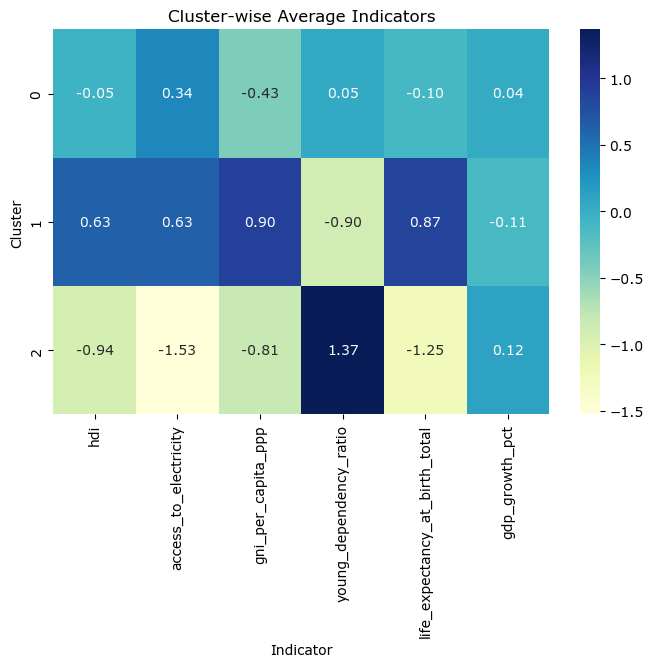

In [21]:
# -------------------------------
# Cluster Summary Heatmap
# -------------------------------
numeric_cols = df_scaled.select_dtypes(include=['number']).columns

cluster_summary = df_scaled.groupby('cluster')[numeric_cols].mean()

# Optional: pick key HDI-related indicators
top_features = ['hdi', 'access_to_electricity', 'gni_per_capita_ppp', 'young_dependency_ratio', 
                'life_expectancy_at_birth_total', 'gdp_growth_pct']
top_features = [f for f in top_features if f in cluster_summary.columns]

plt.figure(figsize=(8,5))
sns.heatmap(cluster_summary[top_features], annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cluster-wise Average Indicators")
plt.ylabel("Cluster")
plt.xlabel("Indicator")
plt.show()

## 17. Model Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'Validation MSE': [lr_mse, tree_mse]
})

results

,Model,Validation MSE
0,Linear Regression,0.664358
1,Decision Tree,0.633148


## 18. Key Insights

### 1. Factors Influencing HDI

Positive Influences (higher HDI associated with higher values):
- Life expectancy at birth – countries with higher life expectancy show stronger HDI outcomes.
- Internet usage and access to electricity – connectivity and basic infrastructure positively correlate with human development.
- Clean fuel access – higher adoption of clean cooking fuels is linked to improved HDI.
- Economic indicators – higher GNI per capita and data infrastructure scores show moderate positive correlation.

Negative Influences (higher values associated with lower HDI):
- Mortality rates – higher infant and under-five mortality significantly reduce HDI.
- Young dependency ratio – a higher proportion of dependents reduces development outcomes.
- Inflation and population growth – moderate negative effect, suggesting economic instability can impact human development.

Correlation evidence:
- Top positive correlations with HDI include life expectancy (0.62), internet users (0.62), clean fuel access (0.57), and access to electricity (0.57).
- Top negative correlations include young dependency ratio (-0.61), under-five mortality (-0.42), and infant deaths (-0.41).

⸻

### 2. Feature Importance Insights
- Decision Tree results highlight non-linear relationships in HDI predictors.
- Most important features:
-     Access to electricity (0.42)
-     Year (0.31)
-     GNI per capita (0.10)
-     Young dependency ratio (0.08)
-     Life expectancy at birth (0.025)
- These results align with correlation findings, emphasizing the role of infrastructure, demographics, and economic factors in human development.

⸻

### 3. Data Processing Observations
- Skewed variables like inflation_pct, number_of_infant_deaths, and oil_rents were handled carefully; log transformations were applied only when values were positive.
- Summary statistics before and after processing show that missing values were effectively handled, and extreme outliers were mitigated, leading to more stable modeling.
- Feature distributions such as clean_fuel_access_pct and access_to_electricity became more normalized after processing.

### 4. Model Performance Comparison

| Model | Validation MSE | 
| :--- | :---: | 
| Linear Regression | 0.664 | 
| Decision Tree | 0.633 | 

- Decision Tree outperforms Linear Regression, highlighting that HDI relationships with predictors are non-linear.
- Linear Regression still captures general trends but may underestimate effects of extreme values or interactions between variables.

⸻

### 5. Clustering Insights
- KMeans clustering groups countries into development levels based on numeric indicators.
- Key cluster characteristics:
-     Cluster 0: Low HDI, high dependency ratios, lower access to infrastructure.
-     Cluster 1: Medium HDI, moderate infrastructure and life expectancy.
-     Cluster 2: High HDI, strong access to electricity, high life expectancy, and internet penetration.
- The cluster summary table and heatmap reveal which countries fall into each cluster and highlight the structural differences between development groups.

⸻

### 6. Overall Takeaways
1. Infrastructure, life expectancy, and technology adoption are the most critical positive drivers of HDI.
2. Demographic pressures and mortality rates are major constraints on human development.
3. Non-linear models like Decision Trees better capture complex relationships in development indicators.
4. Cluster analysis provides a clear segmentation of countries by development stage, useful for policy targeting and comparative studies.